In [1]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer

from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options, Sampler, SamplerV2, RuntimeEncoder, RuntimeDecoder

from qiskit.visualization import plot_histogram, plot_circuit_layout, plot_state_city
from qiskit.circuit.classical import expr
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, reset_error,
    pauli_error, depolarizing_error, thermal_relaxation_error)
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps
from qiskit.circuit.library import RZZGate, RZGate, XGate, IGate
from qiskit.converters import circuit_to_dag, dag_to_circuit
# from qiskit.transpiler.passes import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling, PadDelay, PassManager
from qiskit.qasm2 import dumps
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", instance="free")

# hw_name = "ibm_brisbane"
hw_name = "ibm_torino"
backend = service.backend(hw_name)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

## change later back to 3
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
    )

## change later back to 3
pm_ideal = generate_preset_pass_manager(
    optimization_level=3, backend=sim_ideal
    #, seed_transpiler=12345
    )

management.get:WARNING:2025-11-15 15:30:39,994: Loading default saved account


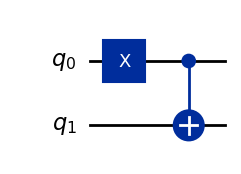

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc = QuantumCircuit(2)
qc.x(0)
qc.cx(0, 1)
qc.draw("mpl")


In [23]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.draw("mpl")

ZZ = SparsePauliOp('ZZZ')
ZI = SparsePauliOp('ZII')
IX = SparsePauliOp('IXI')
IZ = SparsePauliOp('IZI')
XI = SparsePauliOp('XII')
XX = SparsePauliOp('XXX')
observables = [IZ, IX, ZI, XI, ZZ, XX]


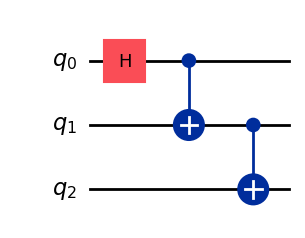

In [24]:
tqc = pm_ideal.run(qc)
tqc.draw("mpl", fold=-1)

In [25]:
transpiled_obs = []
for obs in observables:
    transpiled_obs.append(obs.apply_layout(layout=tqc.layout))

In [54]:
pm = generate_preset_pass_manager(optimization_level=3, backend=sim_ideal)
isa_circuit = pm.run(tqc)
# isa_observable = observable.apply_layout(isa_circuit.layout)
 
precision = 0.015625  / 10
estimator = Estimator(mode=sim_ideal)
job = estimator.run([(isa_circuit, observables, None, 0.015625)], precision=precision)
result = job.result()

print(f">>> {result}")

for res in result:
    print(f"  > Expectation value: {res.data.evs}")
    print(f"  > Metadata: {res.metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(6,), dtype=float64>), stds=np.ndarray(<shape=(6,), dtype=float64>), shape=(6,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})], metadata={'version': 2})
  > Expectation value: [-0.03759766 -0.02880859 -0.03759766  0.03222656 -0.03759766  1.        ]
  > Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}


In [95]:
import numpy as np
 
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
 
 
# Step 1: Map classical inputs to a quantum problem
theta = Parameter("θ")
 
chsh_circuit = QuantumCircuit(2)
chsh_circuit.h(0)
chsh_circuit.cx(0, 1)
chsh_circuit.ry(theta, 0)
 
number_of_phases = 21
phases = np.linspace(0, 2 * np.pi, number_of_phases)
individual_phases = [[ph] for ph in phases]
 
ZZ = SparsePauliOp.from_list([("ZZ", 1)])
ZX = SparsePauliOp.from_list([("ZX", 1)])
XZ = SparsePauliOp.from_list([("XZ", 1)])
XX = SparsePauliOp.from_list([("XX", 1)])
ops = [ZZ, ZX, XZ, XX]
 
# Step 2: Optimize problem for quantum execution.
 
pm = generate_preset_pass_manager(backend=sim_ideal, optimization_level=1)
chsh_isa_circuit = pm.run(chsh_circuit)
isa_observables = [
    operator.apply_layout(chsh_isa_circuit.layout) for operator in ops
]
 
# Step 3: Execute using Qiskit primitives.
 
# Reshape observable array for broadcasting
reshaped_ops = np.fromiter(isa_observables, dtype=object)
reshaped_ops = reshaped_ops.reshape((4,1))

# reshaped_par = np.fromiter(individual_phases, dtype=object)
# reshaped_par = reshaped_par.reshape((3, 7))

 
estimator = Estimator(sim_ideal, options={"default_shots": int(1e4)})
job = estimator.run([(chsh_isa_circuit, reshaped_ops, individual_phases)])
# Get results for the first (and only) PUB
pub_result = job.result()[0]
# print(f">>> Expectation values: {pub_result.data.evs}")
print(f">>> Standard errors: {pub_result.data.stds}")
print(f">>> Metadata: {pub_result.metadata}")

>>> Standard errors: [[0.         0.00304226 0.00578898 0.00815043 0.00946331 0.00999775
  0.00949555 0.00811466 0.00588359 0.0031225  0.         0.0030234
  0.00590004 0.00814046 0.00944817 0.00999996 0.00953308 0.00818715
  0.00587809 0.00314069 0.        ]
 [0.00999999 0.00951967 0.00808133 0.00590825 0.00317076 0.
  0.00306098 0.00588634 0.00813475 0.0095525  0.00999982 0.00949291
  0.00809587 0.00585877 0.00311641 0.         0.00338407 0.00592732
  0.00809442 0.00950802 0.00999948]
 [0.00999999 0.00956601 0.00817309 0.00596518 0.00294667 0.
  0.00301709 0.00598397 0.00809877 0.00953624 0.01       0.00951062
  0.00808279 0.00590278 0.00304226 0.         0.00314673 0.00593817
  0.00805644 0.00948892 0.00999968]
 [0.         0.0031225  0.00582264 0.0081632  0.00946262 0.00999501
  0.00949753 0.00820393 0.0057918  0.00301709 0.         0.00306719
  0.0058643  0.00800599 0.00951516 0.00999966 0.00956479 0.00803874
  0.00599466 0.0031103  0.        ]]
>>> Metadata: {'target_precision': 

In [73]:
result = job.result()


In [76]:
len(result[0].data.evs)

4

In [77]:
len(result[0].data.evs[0])

21